Accuracy: 0.8737835446770864
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93     11966
           1       0.46      0.47      0.47      1598

    accuracy                           0.87     13564
   macro avg       0.70      0.70      0.70     13564
weighted avg       0.87      0.87      0.87     13564



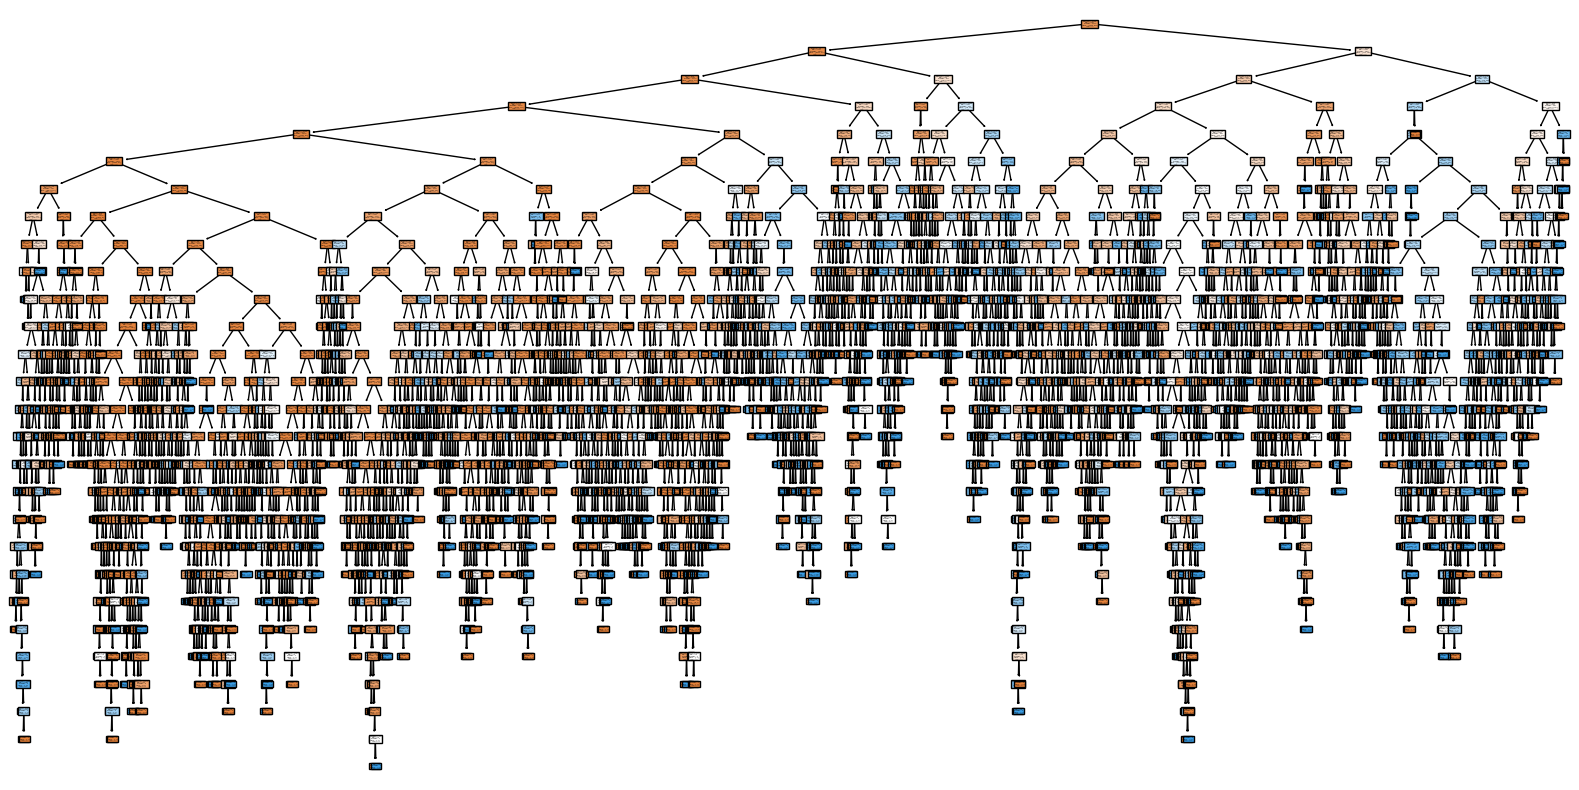

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. Load the data
data = pd.read_csv('/content/bank-full.csv', sep=';')

# 2. Preprocessing
# Encode categorical variables
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Features and target
X = data.drop('y', axis=1)
y = data['y']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 5. Evaluate the model
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 6. Visualize the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=label_encoders['y'].classes_, filled=True)
plt.show()


Accuracy: 0.8979652020053082
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94     11966
           1       0.59      0.44      0.51      1598

    accuracy                           0.90     13564
   macro avg       0.76      0.70      0.72     13564
weighted avg       0.89      0.90      0.89     13564



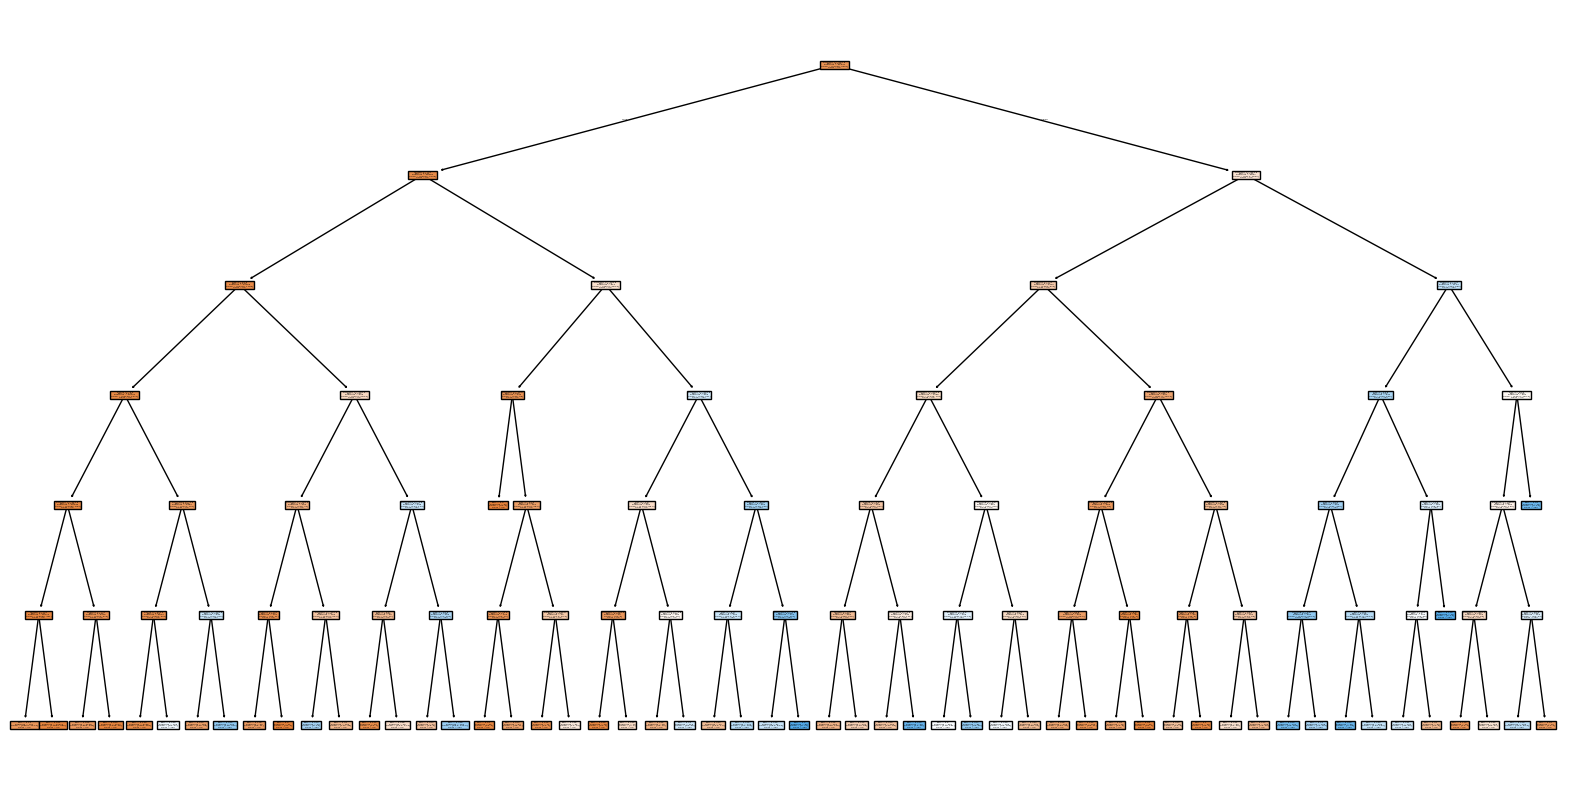

In [ ]:
# Train a Decision Tree with constraints
clf = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,              # Limit tree depth
    min_samples_split=20,     # Minimum samples needed to split
    min_samples_leaf=10,      # Minimum samples at a leaf
)
clf.fit(X_train, y_train)

# Evaluate again
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualize
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=label_encoders['y'].classes_, filled=True)
plt.show()
